# Chapter 4: Basic Quantum Theory

Chapters 1 and 2 built the mathematical toolkit: complex numbers, vector spaces,
linear operators, inner products, tensor products. Chapter 3 showed how these
structures describe physical systems probabilistically and introduced the
critical phenomenon of interference. Now we put those tools to work.

This chapter introduces the formal framework of quantum mechanics in five
moves: quantum states (Section 4.1), observables (Section 4.2), measurement
(Section 4.3), dynamics (Section 4.4), and composite systems (Section 4.5).
Along the way, six postulates will crystallize the rules of the quantum world
into precise mathematical statements. Each one connects back to the linear
algebra you already know.

**Based on Chapter 4 of *Quantum Computing for Computer Scientists* by Yanofsky and Mannucci.**

In [1]:
import numpy as np
from numpy.linalg import norm, eigh, eigvalsh
import matplotlib.pyplot as plt
from functools import reduce

np.set_printoptions(precision=4, suppress=True)

---
## 4.1 Quantum States

At the dawn of the twentieth century, classical mechanics still dominated
physics. Matter was particles; light was waves. Then experiments broke that
clean divide.

The **diffraction experiment** showed beams of subatomic particles producing
wave-like interference patterns. Louis De Broglie proposed in 1924 that all
particles have associated **matter waves**. Meanwhile, the **photoelectric
effect** revealed that light itself comes in discrete packets, **photons**, that
behave as particles. Einstein introduced the concept in 1905. Both matter and
light exhibit particle-like *and* wave-like behavior, depending on how you
observe them.

Young's double-slit experiment captures the strangeness perfectly. Shine
light at a boundary with two narrow slits. On the far side, you see an
interference pattern: bright and dark bands, just as you would expect from
overlapping water waves. Close one slit, and the pattern vanishes.

The astonishing part: this works with a *single photon at a time*. One photon,
two slits, and an interference pattern still emerges. The photon passes through
both slits simultaneously, interferes with itself, and lands according to the
resulting probability distribution. Chapter 3 modeled this with complex-valued
matrices; now we build the general theory.

### A particle confined to a line

Consider a subatomic particle that can be detected at one of $n$ equally spaced
points $\{x_0, x_1, \ldots, x_{n-1}\}$ on a line. We associate each point $x_i$
with a basis vector in $\mathbb{C}^n$, written $|x_i\rangle$ in Dirac **ket**
notation:

$$|x_0\rangle \mapsto [1,0,\ldots,0]^T, \quad |x_1\rangle \mapsto [0,1,\ldots,0]^T, \quad \ldots \quad |x_{n-1}\rangle \mapsto [0,0,\ldots,1]^T.$$

An arbitrary **state** of the particle is a **superposition** of these basis
states:

$$|\psi\rangle = c_0|x_0\rangle + c_1|x_1\rangle + \cdots + c_{n-1}|x_{n-1}\rangle = [c_0, c_1, \ldots, c_{n-1}]^T \in \mathbb{C}^n.$$

The complex numbers $c_0, c_1, \ldots, c_{n-1}$ are called **complex amplitudes**.
The probability of detecting the particle at position $x_i$ after measurement is:

$$p(x_i) = \frac{|c_i|^2}{\sum_j |c_j|^2}.$$

Multiplying a ket by any nonzero complex scalar does not change the physical
state (the probabilities stay the same). So we often work with **normalized**
states, where $\sum_j |c_j|^2 = 1$, which simplifies the probability formula to
$p(x_i) = |c_i|^2$.

In [2]:
# Example 4.1.1: probability of finding a particle at x_2
psi = np.array([-3-1j, -2j, 1j, 2])
norm_psi = norm(psi)
prob_x2 = abs(psi[2])**2 / norm_psi**2

print(f"State |psi> = {psi}")
print(f"Norm: {norm_psi:.4f}")
print(f"P(x_2) = |i|^2 / {norm_psi:.4f}^2 = {prob_x2:.6f}")
print()

# All probabilities
probs = np.abs(psi)**2 / norm_psi**2
print("All probabilities:", np.round(probs, 6))
print("Sum:", round(probs.sum(), 6))

State |psi> = [-3.-1.j -0.-2.j  0.+1.j  2.+0.j]
Norm: 4.3589
P(x_2) = |i|^2 / 4.3589^2 = 0.052632

All probabilities: [0.5263 0.2105 0.0526 0.2105]
Sum: 1.0


### Normalization

Since scalar multiples of a ket represent the same physical state, we can
always normalize by dividing by the norm:

$$|\psi\rangle_{\text{normalized}} = \frac{|\psi\rangle}{\||\psi\rangle\|}.$$

For a normalized state, $p(x_i) = |c_i|^2$ directly.

In [3]:
# Example 4.1.3: normalize a vector
v = np.array([2-3j, 1+2j])
v_norm = norm(v)
v_normalized = v / v_norm

print(f"Original: {v}, norm = {v_norm:.4f}")
print(f"Normalized: {np.round(v_normalized, 5)}")
print(f"Norm check: {norm(v_normalized):.6f}")

Original: [2.-3.j 1.+2.j], norm = 4.2426
Normalized: [0.4714-0.7071j 0.2357+0.4714j]
Norm check: 1.000000


### Spin states

Spin is a quantum property with no classical analog. The **Stern-Gerlach
experiment** (1922) sent electrons through an inhomogeneous magnetic field and
found they always deflect to one of exactly two spots: spin **up** $|\!\uparrow\rangle$
or spin **down** $|\!\downarrow\rangle$. Nothing in between, despite the electrons
arriving unprepared.

A general spin state is a superposition:

$$|\psi\rangle = c_0|\!\uparrow\rangle + c_1|\!\downarrow\rangle,$$

a vector in $\mathbb{C}^2$. The probability of measuring spin up is $|c_0|^2 / (|c_0|^2 + |c_1|^2)$.

In [4]:
# Example 4.1.4: spin probability
psi_spin = np.array([3-4j, 7+2j])  # c_0|up> + c_1|down>
norm_spin = norm(psi_spin)

p_up = abs(psi_spin[0])**2 / norm_spin**2
p_down = abs(psi_spin[1])**2 / norm_spin**2

print(f"Spin state: ({psi_spin[0]})|up> + ({psi_spin[1]})|down>")
print(f"Norm: {norm_spin:.4f}")
print(f"P(up)   = |3-4i|^2 / {norm_spin:.4f}^2 = 25/78 = {p_up:.6f}")
print(f"P(down) = |7+2i|^2 / {norm_spin:.4f}^2 = 53/78 = {p_down:.6f}")
print(f"Sum: {p_up + p_down:.6f}")

Spin state: ((3-4j))|up> + ((7+2j))|down>
Norm: 8.8318
P(up)   = |3-4i|^2 / 8.8318^2 = 25/78 = 0.320513
P(down) = |7+2i|^2 / 8.8318^2 = 53/78 = 0.679487
Sum: 1.000000


### Bra-ket notation and transition amplitudes

The **bra** corresponding to a ket $|\psi\rangle = [c_0, c_1, \ldots, c_{n-1}]^T$
is the conjugate-transpose row vector:

$$\langle\psi| = [\overline{c_0}, \overline{c_1}, \ldots, \overline{c_{n-1}}].$$

The **transition amplitude** from state $|\psi\rangle$ to state $|\phi\rangle$ is
their inner product $\langle\phi|\psi\rangle$. Its modulus squared,
$|\langle\phi|\psi\rangle|^2$, gives the probability that a system in state
$|\psi\rangle$ will be found in state $|\phi\rangle$ after measurement (assuming
both states are normalized; otherwise divide by the product of their norms).

Orthogonal states ($\langle\phi|\psi\rangle = 0$) are **mutually exclusive**: a
system in one can never be found in the other. The basis states
$\{|x_0\rangle, |x_1\rangle, \ldots\}$ form an **orthonormal basis**, as do
$\{|\!\uparrow\rangle, |\!\downarrow\rangle\}$.

In [5]:
# Example 4.1.7: transition amplitude
psi = np.array([1, -1j])
phi = np.array([1j, 1])

# Inner product <phi|psi>
amplitude = np.vdot(phi, psi)  # np.vdot conjugates the first argument
print(f"|psi> = {psi}")
print(f"|phi> = {phi}")
print(f"<phi|psi> = {amplitude}")
print(f"|<phi|psi>|^2 / (||phi|| * ||psi||)^2 = {abs(amplitude)**2 / (norm(phi)**2 * norm(psi)**2):.4f}")

# Normalized version
psi_n = psi / norm(psi)
phi_n = phi / norm(phi)
amp_n = np.vdot(phi_n, psi_n)
print(f"\nNormalized: <phi|psi> = {amp_n}")
print(f"Transition probability = |<phi|psi>|^2 = {abs(amp_n)**2:.4f}")

|psi> = [ 1.+0.j -0.-1.j]
|phi> = [0.+1.j 1.+0.j]
<phi|psi> = -2j
|<phi|psi>|^2 / (||phi|| * ||psi||)^2 = 1.0000

Normalized: <phi|psi> = -0.9999999999999998j
Transition probability = |<phi|psi>|^2 = 1.0000


### Summary of Section 4.1

- A quantum system's state space is a complex vector space $\mathbb{C}^n$.
  The dimension equals the number of distinguishable basic states.
- States can be superposed (added as vectors). Scalar multiples of a state
  represent the same physical system.
- The inner product gives the state space a geometry with physical meaning:
  transition amplitudes describe how likely one state is to become another
  upon measurement. Orthogonal states are mutually exclusive.

### Programming Drill 4.1.1: Quantum state simulator

Simulate the particle-on-a-line system. Given a ket (state vector), compute
the probability of finding the particle at each position. Given two kets,
compute the transition amplitude.

In [6]:
def quantum_state_sim(ket):
    """Given a state vector, return position probabilities."""
    probs = np.abs(ket)**2 / norm(ket)**2
    return probs

def transition_amplitude(ket_start, ket_end):
    """Transition amplitude from ket_start to ket_end."""
    return np.vdot(ket_end, ket_start) / (norm(ket_start) * norm(ket_end))

# Test: particle on 6 points
psi = np.array([2-1j, 2j, 1-1j, 1, -2j, 2])
probs = quantum_state_sim(psi)
print("State:", psi)
print("Probabilities:", np.round(probs, 4))
print(f"Sum of probabilities: {probs.sum():.6f}")

# Transition between two states
phi = np.array([1+1j, 0, -1j, 2, 1-1j, 0])
amp = transition_amplitude(psi, phi)
print(f"\nTransition amplitude <phi|psi>: {amp:.4f}")
print(f"Transition probability: {abs(amp)**2:.4f}")

State: [ 2.-1.j  0.+2.j  1.-1.j  1.+0.j -0.-2.j  2.+0.j]
Probabilities: [0.25 0.2  0.1  0.05 0.2  0.2 ]
Sum of probabilities: 1.000000

Transition amplitude <phi|psi>: 0.4472-0.2981j
Transition probability: 0.2889


---
## 4.2 Observables

Physics is about observation: mass, momentum, velocity, energy. These are
the measurable quantities of a system, and quantum mechanics has a precise way
to represent them.

Think of a physical system as specified by two lists: the states it can
occupy, and the physical quantities (observables) you can measure on it. We
have already modeled the first list with vectors. Now for the second.

### Postulate 4.2.1

> **To each physical observable there corresponds a hermitian operator.**

An observable is a linear operator (a matrix) that maps states to states.
The requirement that it be hermitian ($\Omega = \Omega^\dagger$) ensures
its eigenvalues are real, which makes sense: the result of a physical
measurement had better be a real number.

In [7]:
# The observable Omega from Example 4.2.1
Omega = np.array([[-1, -1j],
                   [1j, 1]])

# Verify hermitian: Omega = Omega^dagger
print("Omega:")
print(Omega)
print(f"\nIs hermitian? {np.allclose(Omega, Omega.conj().T)}")

# Apply to a state
psi = np.array([-1, -1-1j])
result = Omega @ psi
print(f"\n|psi> = {psi}")
print(f"Omega|psi> = {result}")

Omega:
[[-1.+0.j -0.-1.j]
 [ 0.+1.j  1.+0.j]]

Is hermitian? True

|psi> = [-1.+0.j -1.-1.j]
Omega|psi> = [ 0.+1.j -1.-2.j]


### Postulate 4.2.2

> **The eigenvalues of the hermitian operator $\Omega$ are the only possible
> values observable as a result of measuring it on any given state.
> Furthermore, the eigenvectors of $\Omega$ form a basis for the state space.**

Each observable represents a question we pose to the system. The eigenvalues
are the only answers we can ever get back.

### Position and spin observables

For the particle on a line, the most natural observable is **position**:
"Where is the particle?" The corresponding hermitian operator is the diagonal
matrix $P = \text{diag}(x_0, x_1, \ldots, x_{n-1})$. Its eigenvalues are the
positions themselves, and its eigenvectors are the basis states $|x_i\rangle$.

For the spin system, the typical question is: along a given spatial axis, is
the particle spinning clockwise or counterclockwise? The three **Pauli spin
matrices** (ignoring the constant $\hbar/2$) capture the three spatial
directions:

$$S_z = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, \quad S_x = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \quad S_y = \begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}.$$

Each comes with its own eigenbasis. $S_z$ has eigenbasis $\{|\!\uparrow\rangle, |\!\downarrow\rangle\}$
(up/down). $S_x$ has $\{|\!\leftarrow\rangle, |\!\rightarrow\rangle\}$ (left/right).
$S_y$ has its own pair (in/out).

In [8]:
# Pauli spin matrices
Sz = np.array([[1, 0], [0, -1]], dtype=complex)
Sx = np.array([[0, 1], [1, 0]], dtype=complex)
Sy = np.array([[0, -1j], [1j, 0]])

for name, mat in [("Sz", Sz), ("Sx", Sx), ("Sy", Sy)]:
    eigenvalues, eigenvectors = eigh(mat)
    print(f"{name}:")
    print(f"  Hermitian? {np.allclose(mat, mat.conj().T)}")
    print(f"  Eigenvalues: {eigenvalues}")
    print(f"  Eigenvectors (columns):")
    print(f"    {np.round(eigenvectors, 4)}")
    print()

Sz:
  Hermitian? True
  Eigenvalues: [-1.  1.]
  Eigenvectors (columns):
    [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Sx:
  Hermitian? True
  Eigenvalues: [-1.  1.]
  Eigenvectors (columns):
    [[-0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]

Sy:
  Hermitian? True
  Eigenvalues: [-1.  1.]
  Eigenvectors (columns):
    [[-0.7071-0.j     -0.7071+0.j    ]
 [ 0.    +0.7071j  0.    -0.7071j]]



### Commutators

Matrix multiplication is not commutative: for operators $\Omega_1$ and
$\Omega_2$, we generally have $\Omega_1 \Omega_2 \neq \Omega_2 \Omega_1$.
The **commutator** measures how far two operators are from commuting:

$$[\Omega_1, \Omega_2] = \Omega_1 \Omega_2 - \Omega_2 \Omega_1.$$

If the commutator is the zero matrix, the operators commute, and their product
(in either order) is itself hermitian. If not, the product of the two
hermitian operators need not be hermitian.

The Pauli spin matrices provide a beautiful example. None of the three pairs
commute:

In [9]:
# Commutators of spin matrices (ignoring hbar/2)
def commutator(A, B):
    return A @ B - B @ A

comm_xy = commutator(Sx, Sy)
comm_yz = commutator(Sy, Sz)
comm_zx = commutator(Sz, Sx)

print("[Sx, Sy] =")
print(comm_xy)
print(f"  = 2i * Sz? {np.allclose(comm_xy, 2j * Sz)}")
print()
print("[Sy, Sz] =")
print(comm_yz)
print(f"  = 2i * Sx? {np.allclose(comm_yz, 2j * Sx)}")
print()
print("[Sz, Sx] =")
print(comm_zx)
print(f"  = 2i * Sy? {np.allclose(comm_zx, 2j * Sy)}")

[Sx, Sy] =
[[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]
  = 2i * Sz? True

[Sy, Sz] =
[[0.+0.j 0.+2.j]
 [0.+2.j 0.+0.j]]
  = 2i * Sx? True

[Sz, Sx] =
[[ 0.+0.j  2.+0.j]
 [-2.+0.j  0.+0.j]]
  = 2i * Sy? True


### Postulate 4.2.3

> **$\langle\Omega\rangle_\psi = \langle\psi|\Omega|\psi\rangle$ is the expected
> value of observing $\Omega$ repeatedly on the same state $\psi$.**

Prepare many identical copies of the system in state $|\psi\rangle$. Measure
the observable on each. The eigenvalues $\lambda_0, \lambda_1, \ldots$ appear
with certain frequencies. The weighted average of these eigenvalues converges
to $\langle\psi|\Omega|\psi\rangle$.

More concretely, if $|\psi\rangle = c_0|e_0\rangle + \cdots + c_{n-1}|e_{n-1}\rangle$
in the eigenbasis of $\Omega$, then:

$$\langle\Omega\rangle_\psi = |c_0|^2\lambda_0 + |c_1|^2\lambda_1 + \cdots + |c_{n-1}|^2\lambda_{n-1}.$$

In [10]:
# Example 4.2.5: expected value
psi = np.array([np.sqrt(2)/2, np.sqrt(2)/2*1j])
Omega = np.array([[1, -1j], [1j, 2]])

# Verify hermitian
print(f"Omega hermitian? {np.allclose(Omega, Omega.conj().T)}")

# Expected value = <psi|Omega|psi>
expected = np.vdot(psi, Omega @ psi).real
print(f"|psi> = {np.round(psi, 4)}")
print(f"Omega|psi> = {np.round(Omega @ psi, 4)}")
print(f"<Omega> = {expected:.4f}")

Omega hermitian? True
|psi> = [0.7071+0.j     0.    +0.7071j]
Omega|psi> = [1.4142+0.j     0.    +2.1213j]
<Omega> = 2.5000


### Variance

The expected value tells us the average measurement result. The **variance**
tells us how spread out the results are around that average.

Define the "demeaned" operator: $\Delta_\psi(\Omega) = \Omega - \langle\Omega\rangle_\psi I$.
This subtracts the mean from the observable. Its expected value on $|\psi\rangle$
is exactly zero.

The variance is the expected value of the squared demeaned operator:

$$\text{Var}_\psi(\Omega) = \langle(\Delta_\psi(\Omega))^2\rangle_\psi = \langle\psi|\Delta_\psi(\Omega)^2|\psi\rangle.$$

On an eigenvector, the variance is zero: you always get the same eigenvalue,
with no spread at all.

In [11]:
# Example 4.2.7: computing variance
psi = np.array([np.sqrt(2)/2, np.sqrt(2)/2*1j])
Omega = np.array([[1, -1j], [1j, 2]])

# Expected value
mu = np.vdot(psi, Omega @ psi).real
print(f"Expected value (mu): {mu}")

# Delta = Omega - mu*I
I2 = np.eye(2)
Delta = Omega - mu * I2
print(f"\nDelta(Omega) = Omega - {mu}*I =")
print(np.round(Delta, 4))

# Delta^2
Delta_sq = Delta @ Delta
print(f"\nDelta^2 =")
print(np.round(Delta_sq, 4))

# Variance = <psi|Delta^2|psi>
variance = np.vdot(psi, Delta_sq @ psi).real
print(f"\nVariance = {variance}")

Expected value (mu): 2.5000000000000004

Delta(Omega) = Omega - 2.5000000000000004*I =
[[-1.5+0.j -0. -1.j]
 [ 0. +1.j -0.5+0.j]]

Delta^2 =
[[3.25+0.j 0.  +2.j]
 [0.  -2.j 1.25+0.j]]

Variance = 0.25


### Theorem 4.2.1: Heisenberg's Uncertainty Principle

> **The product of the variances of two hermitian operators on a given state
> is always greater than or equal to one-fourth the square of the expected
> value of their commutator:**
>
> $$\text{Var}_\psi(\Omega_1) \times \text{Var}_\psi(\Omega_2) \geq \frac{1}{4}|\langle[\Omega_1, \Omega_2]\rangle_\psi|^2.$$

If two observables do not commute, you cannot simultaneously know both with
arbitrary precision. Sharpening your knowledge of one necessarily blurs the
other. The spin operators give a concrete example: because $[S_x, S_y] = 2iS_z
\neq 0$, you can never simultaneously pin down spin in both the $x$ and $y$
directions.

In [12]:
# Heisenberg uncertainty demo with spin operators
def expected_value(psi, Op):
    """<psi|Op|psi> for normalized psi."""
    return np.vdot(psi, Op @ psi).real

def variance(psi, Op):
    """Var_psi(Op) for normalized psi."""
    mu = expected_value(psi, Op)
    Delta = Op - mu * np.eye(len(psi))
    return np.vdot(psi, (Delta @ Delta) @ psi).real

# Test on several spin states
states = {
    "|up>": np.array([1, 0], dtype=complex),
    "|down>": np.array([0, 1], dtype=complex),
    "(|up>+|down>)/sqrt(2)": np.array([1, 1], dtype=complex) / np.sqrt(2),
    "(|up>+i|down>)/sqrt(2)": np.array([1, 1j]) / np.sqrt(2),
}

print("Heisenberg check: Var(Sx)*Var(Sy) >= (1/4)|<[Sx,Sy]>|^2")
print("Since [Sx,Sy] = 2i*Sz, the RHS = |<2i*Sz>|^2 / 4 = |<Sz>|^2\n")

comm = commutator(Sx, Sy)
for name, psi in states.items():
    var_x = variance(psi, Sx)
    var_y = variance(psi, Sy)
    lhs = var_x * var_y
    rhs = abs(expected_value(psi, comm))**2 / 4
    print(f"  {name}:")
    print(f"    Var(Sx)={var_x:.4f}, Var(Sy)={var_y:.4f}, product={lhs:.4f}")
    print(f"    (1/4)|<[Sx,Sy]>|^2 = {rhs:.4f}")
    print(f"    {lhs:.4f} >= {rhs:.4f}? {lhs >= rhs - 1e-10}")
    print()

Heisenberg check: Var(Sx)*Var(Sy) >= (1/4)|<[Sx,Sy]>|^2
Since [Sx,Sy] = 2i*Sz, the RHS = |<2i*Sz>|^2 / 4 = |<Sz>|^2

  |up>:
    Var(Sx)=1.0000, Var(Sy)=1.0000, product=1.0000
    (1/4)|<[Sx,Sy]>|^2 = 0.0000
    1.0000 >= 0.0000? True

  |down>:
    Var(Sx)=1.0000, Var(Sy)=1.0000, product=1.0000
    (1/4)|<[Sx,Sy]>|^2 = 0.0000
    1.0000 >= 0.0000? True

  (|up>+|down>)/sqrt(2):
    Var(Sx)=0.0000, Var(Sy)=1.0000, product=0.0000
    (1/4)|<[Sx,Sy]>|^2 = 0.0000
    0.0000 >= 0.0000? True

  (|up>+i|down>)/sqrt(2):
    Var(Sx)=1.0000, Var(Sy)=0.0000, product=0.0000
    (1/4)|<[Sx,Sy]>|^2 = 0.0000
    0.0000 >= 0.0000? True



### Programming Drill 4.2.1: Observable simulator

Given a hermitian matrix and a state vector, verify the matrix is hermitian,
compute the expected value, and compute the variance.

In [13]:
def observable_sim(Omega, psi):
    """Verify hermitian, compute expected value and variance."""
    is_herm = np.allclose(Omega, Omega.conj().T)
    if not is_herm:
        print("WARNING: Matrix is not hermitian!")
        return None, None

    # Normalize
    psi_n = psi / norm(psi)

    mu = expected_value(psi_n, Omega)
    var = variance(psi_n, Omega)

    return mu, var

# Test with Sz on the equal superposition state
psi_test = np.array([1, 1], dtype=complex) / np.sqrt(2)
mu, var = observable_sim(Sz, psi_test)
print(f"Observable: Sz on (|up>+|down>)/sqrt(2)")
print(f"Expected value: {mu:.4f}")
print(f"Variance: {var:.4f}")
print()

# Test on an eigenvector: variance should be 0
mu_eig, var_eig = observable_sim(Sz, np.array([1, 0], dtype=complex))
print(f"Observable: Sz on |up>")
print(f"Expected value: {mu_eig:.4f}")
print(f"Variance: {var_eig:.4f} (zero: we always get the same eigenvalue)")

Observable: Sz on (|up>+|down>)/sqrt(2)
Expected value: 0.0000
Variance: 1.0000

Observable: Sz on |up>
Expected value: 1.0000
Variance: 0.0000 (zero: we always get the same eigenvalue)


---
## 4.3 Measuring

Classical physics assumed that measurement leaves a system undisturbed and
that outcomes are fully predictable from a known state. At the quantum scale,
both assumptions fail. Measurement *changes* the system, and the outcome is
inherently probabilistic.

### Postulate 4.3.1

> **Let $\Omega$ be an observable and $|\psi\rangle$ a state. If the result of
> measuring $\Omega$ is the eigenvalue $\lambda$, the state after measurement
> will always be the eigenvector corresponding to $\lambda$.**

The system "collapses" from its superposition into one of the eigenstates.
The probability of collapsing to eigenvector $|e_i\rangle$ with eigenvalue
$\lambda_i$ is:

$$p_i = |\langle e_i | \psi \rangle|^2,$$

the squared length of the projection of $|\psi\rangle$ onto $|e_i\rangle$.
After collapse, repeating the same measurement immediately yields the same
eigenvalue with certainty.

In [14]:
# Example 4.3.1: measurement collapse
Omega = np.array([[-1, -1j],
                   [1j, 1]], dtype=complex)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(Omega)
print("Observable Omega:")
print(Omega)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):")
print(np.round(eigenvectors, 4))

# State psi = (1/2)[1, 1]^T
psi = np.array([1, 1], dtype=complex) / 2
psi = psi / norm(psi)  # normalize

print(f"\nState |psi> = {np.round(psi, 4)}")

# Probability of each eigenvalue
for i in range(len(eigenvalues)):
    e_i = eigenvectors[:, i]
    prob = abs(np.vdot(e_i, psi))**2
    print(f"P(lambda={eigenvalues[i]:.4f}) = |<e{i}|psi>|^2 = {prob:.4f}")
    print(f"  Post-measurement state: {np.round(e_i, 4)}")

Observable Omega:
[[-1.+0.j -0.-1.j]
 [ 0.+1.j  1.+0.j]]

Eigenvalues: [-1.4142  1.4142]
Eigenvectors (columns):
[[-0.9239-0.j     -0.3827+0.j    ]
 [ 0.    +0.3827j  0.    -0.9239j]]

State |psi> = [0.7071+0.j 0.7071+0.j]
P(lambda=-1.4142) = |<e0|psi>|^2 = 0.5000
  Post-measurement state: [-0.9239-0.j      0.    +0.3827j]
P(lambda=1.4142) = |<e1|psi>|^2 = 0.5000
  Post-measurement state: [-0.3827+0.j      0.    -0.9239j]


### Three polarization sheets

Polarization provides an elegant physical demonstration. Shoot polarized
light through two orthogonal polarization sheets, and nothing gets through.
Now insert a third sheet between them at 45 degrees. Light passes through
all three.

The explanation is pure measurement mechanics. The first sheet collapses the
photon to vertical polarization. The middle sheet, oriented diagonally,
measures in the diagonal basis: the vertically polarized photon is now a
superposition of the diagonal basis states, so half the light passes. That
light is now diagonally polarized, which is itself a superposition of
vertical and horizontal. The final sheet measures in the vertical/horizontal
basis again, passing half. Net result: one-eighth of the original light
makes it through, because the middle sheet changed the question.

In [15]:
# Polarization simulation
# Basis: |V> = [1,0], |H> = [0,1]
# Diagonal basis: |D+> = [1,1]/sqrt(2), |D-> = [1,-1]/sqrt(2)

def measure_in_basis(state, basis_vectors):
    """Return (probabilities, collapsed_states) for measurement in given basis."""
    probs = []
    for bv in basis_vectors:
        bv_n = bv / norm(bv)
        p = abs(np.vdot(bv_n, state))**2
        probs.append(p)
    return np.array(probs)

V = np.array([1, 0], dtype=complex)
H = np.array([0, 1], dtype=complex)
D_plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
D_minus = np.array([1, -1], dtype=complex) / np.sqrt(2)

# Start: vertically polarized photon
state = V.copy()
print("1. Start: vertical polarization |V>")

# Sheet 1: vertical filter (passes vertical, blocks horizontal)
print("2. First sheet (vertical): passes, state stays |V>")

# Sheet 2: diagonal filter at 45 degrees
probs_diag = measure_in_basis(state, [D_plus, D_minus])
print(f"3. Middle sheet (45 deg): P(pass) = {probs_diag[0]:.4f}")
state = D_plus  # collapses to diagonal
print(f"   State collapses to |D+> = {np.round(state, 4)}")

# Sheet 3: horizontal filter
probs_vh = measure_in_basis(state, [V, H])
print(f"4. Last sheet (horizontal): P(pass) = {probs_vh[1]:.4f}")

total = 1.0 * probs_diag[0] * probs_vh[1]
print(f"\nFraction passing middle and last sheets: {total:.4f}")
print("(The first vertical sheet passes half the unpolarized light;")
print(" of that, 1/2 passes the diagonal, and 1/2 of that passes horizontal.")
print(" Net: 1/2 * 1/2 * 1/2 = 1/8 of the original unpolarized light.")

1. Start: vertical polarization |V>
2. First sheet (vertical): passes, state stays |V>
3. Middle sheet (45 deg): P(pass) = 0.5000
   State collapses to |D+> = [0.7071+0.j 0.7071+0.j]
4. Last sheet (horizontal): P(pass) = 0.5000

Fraction passing middle and last sheets: 0.2500
(The first vertical sheet passes half the unpolarized light;
 of that, 1/2 passes the diagonal, and 1/2 of that passes horizontal.
 Net: 1/2 * 1/2 * 1/2 = 1/8 of the original unpolarized light.


### Programming Drill 4.3.1: Measurement simulator

Given an observable (hermitian matrix) and a state vector, compute the
eigenvalues, the probability of each measurement outcome, and the
post-measurement state.

Measuring Sx on |up>:

Expected value: 0.0000
Variance: 1.0000

Possible outcomes:
  Eigenvalue -1.0000: probability 0.5000, post-state = [-0.7071+0.j  0.7071+0.j]
  Eigenvalue +1.0000: probability 0.5000, post-state = [0.7071+0.j 0.7071+0.j]


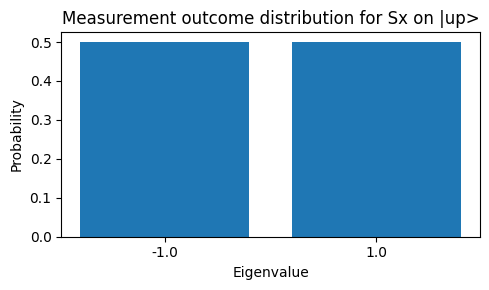

In [16]:
def measurement_sim(Omega, psi):
    """
    Simulate quantum measurement.
    Returns eigenvalues, probabilities, and post-measurement states.
    """
    # Verify hermitian
    assert np.allclose(Omega, Omega.conj().T), "Observable must be hermitian!"

    # Normalize state
    psi_n = psi / norm(psi)

    # Eigendecomposition
    eigenvalues, eigenvectors = eigh(Omega)

    # Expected value
    mu = expected_value(psi_n, Omega)
    var = variance(psi_n, Omega)

    print(f"Expected value: {mu:.4f}")
    print(f"Variance: {var:.4f}")
    print(f"\nPossible outcomes:")

    probs = []
    for i in range(len(eigenvalues)):
        e_i = eigenvectors[:, i]
        p = abs(np.vdot(e_i, psi_n))**2
        probs.append(p)
        print(f"  Eigenvalue {eigenvalues[i]:+.4f}: "
              f"probability {p:.4f}, "
              f"post-state = {np.round(e_i, 4)}")

    return eigenvalues, np.array(probs), eigenvectors

# Demo: measure Sx on spin-up state
print("Measuring Sx on |up>:\n")
eigenvalues, probs, eigvecs = measurement_sim(Sx, np.array([1, 0], dtype=complex))

# Visualize probability distribution
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(len(eigenvalues)), probs, tick_label=[f'{ev:.1f}' for ev in eigenvalues])
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Probability')
ax.set_title('Measurement outcome distribution for Sx on |up>')
plt.tight_layout()
plt.show()

---
## 4.4 Dynamics

So far, the framework has been static: states, observables, measurements.
Real quantum systems evolve over time, and we need a way to describe that
evolution.

### Postulate 4.4.1

> **The evolution of a quantum system (that is not a measurement) is given
> by a unitary operator or transformation.**

If $U$ is a unitary matrix and $|\psi(t)\rangle$ is the state at time $t$, then
the state at time $t+1$ is:

$$|\psi(t+1)\rangle = U|\psi(t)\rangle.$$

Unitary transformations preserve the norm of the state vector (probabilities
still sum to 1), they are invertible ($U^\dagger U = I$), and their
composition is also unitary. This means quantum dynamics is reversible: you
can always run the movie backward by applying $U^\dagger$.

In [17]:
# Verify unitary matrices from Exercise 4.4.1
U1 = np.array([[0, 1], [1, 0]], dtype=complex)
U2 = np.array([[np.sqrt(2)/2, np.sqrt(2)/2],
               [np.sqrt(2)/2, -np.sqrt(2)/2]])

for name, U in [("U1", U1), ("U2", U2)]:
    product = U.conj().T @ U
    print(f"{name} unitary? {np.allclose(product, np.eye(2))}")

# Their product is also unitary
U12 = U1 @ U2
print(f"U1*U2 unitary? {np.allclose(U12.conj().T @ U12, np.eye(2))}")
print(f"\nU1*U2 =")
print(np.round(U12, 4))

U1 unitary? True
U2 unitary? True
U1*U2 unitary? True

U1*U2 =
[[ 0.7071+0.j -0.7071+0.j]
 [ 0.7071+0.j  0.7071+0.j]]


### Orbits

Given an initial state $|\psi\rangle$ and a sequence of unitary matrices
$\mathfrak{U}[t_0], \mathfrak{U}[t_1], \ldots, \mathfrak{U}[t_{n-1}]$,
the **orbit** is the sequence of states obtained by applying them one after
another:

$$|\psi\rangle \xrightarrow{\mathfrak{U}[t_0]} \mathfrak{U}[t_0]|\psi\rangle \xrightarrow{\mathfrak{U}[t_1]} \mathfrak{U}[t_1]\mathfrak{U}[t_0]|\psi\rangle \xrightarrow{\mathfrak{U}[t_2]} \cdots$$

Because each step is unitary, we can always reverse: apply $\mathfrak{U}[t_i]^\dagger$
to go back one step. A quantum computation follows exactly this pattern:
prepare an initial state, apply a sequence of unitary operators, then measure.

### The Schrodinger equation

How does nature choose which unitary transformations to apply? The answer is
the **Schrodinger equation**:

$$\frac{|\psi(t + \delta t)\rangle - |\psi(t)\rangle}{\delta t} = -i\frac{2\pi}{\hbar}\mathcal{H}|\psi(t)\rangle,$$

where $\mathcal{H}$ is a hermitian operator called the **hamiltonian** of the
system. The hamiltonian represents the total energy of the system. Classical
mechanics taught that energy is conserved; quantum mechanics encodes this
conservation law in the hamiltonian, which drives the unitary evolution.

### Programming Drill 4.4.1: Orbit computation

Given an initial state and a sequence of unitary matrices, compute the orbit
(the state vector after applying all the matrices in sequence).

In [18]:
def compute_orbit(psi, unitaries):
    """
    Apply a sequence of unitary matrices to an initial state.
    Returns the list of states at each time step.
    """
    states = [psi.copy()]
    current = psi.copy()
    for U in unitaries:
        assert np.allclose(U.conj().T @ U, np.eye(len(U))), "Matrix not unitary!"
        current = U @ current
        states.append(current.copy())
    return states

# Quantum billiard ball (Example 3.3.2 revisited)
A = np.array([[0, 1/np.sqrt(2), 1/np.sqrt(2), 0],
              [1j/np.sqrt(2), 0, 0, 1/np.sqrt(2)],
              [1/np.sqrt(2), 0, 0, 1j/np.sqrt(2)],
              [0, -1/np.sqrt(2), 1/np.sqrt(2), 0]], dtype=complex)

print(f"Unitary? {np.allclose(A.conj().T @ A, np.eye(4))}")

psi_0 = np.array([1, 0, 0, 0], dtype=complex)

# Apply same unitary 4 times
orbit = compute_orbit(psi_0, [A, A, A, A])

print("\nOrbit of quantum billiard ball:")
for t, state in enumerate(orbit):
    probs = np.abs(state)**2
    print(f"  t={t}: state = {np.round(state, 4)}, "
          f"probs = {np.round(probs, 4)}")

# After 2 steps, we should be back at vertex 0
print(f"\nBack to start after 2 steps? {np.allclose(orbit[2], psi_0)}")

Unitary? True

Orbit of quantum billiard ball:
  t=0: state = [1.+0.j 0.+0.j 0.+0.j 0.+0.j], probs = [1. 0. 0. 0.]
  t=1: state = [0.    +0.j     0.    +0.7071j 0.7071+0.j     0.    +0.j    ], probs = [0.  0.5 0.5 0. ]
  t=2: state = [0.5+0.5j 0. +0.j  0. +0.j  0.5-0.5j], probs = [0.5 0.  0.  0.5]
  t=3: state = [0.    +0.j     0.    +0.j     0.7071+0.7071j 0.    +0.j    ], probs = [0. 0. 1. 0.]
  t=4: state = [0.5+0.5j 0. +0.j  0. +0.j  0.5+0.5j], probs = [0.5 0.  0.  0.5]

Back to start after 2 steps? False


---
## 4.5 Assembling Quantum Systems

So far, each system has lived alone. The real power of quantum mechanics
emerges when we combine systems. Two particles on separate grids, two
spinning electrons, a particle and a measuring device: all are composite
systems built from simpler ones.

Chapter 3 showed that the classical way to combine systems is the Cartesian
product of their state spaces, with the tensor product (Kronecker product)
of their transition matrices. The quantum version is the same construction,
with one astonishing twist.

### Postulate 4.5.1 (Tensor product for composite systems)

> **If two independent quantum systems $Q$ and $Q'$ have state spaces
> $\mathbb{V}$ and $\mathbb{V}'$, the composite system $Q \otimes Q'$ has
> state space $\mathbb{V} \otimes \mathbb{V}'$.**

The tensor product is associative, so we can build systems of any number of
subsystems: $\mathbb{V}_0 \otimes \mathbb{V}_1 \otimes \cdots \otimes \mathbb{V}_k$.

For two particles on grids of size $n$ and $m$, the composite state space is
$\mathbb{C}^{n \times m}$. The basis states are tensor products
$|x_i\rangle \otimes |y_j\rangle$, representing particle 1 at $x_i$ and
particle 2 at $y_j$.

In [19]:
# Example 4.5.1: two particles, n=2, m=2
# State space is C^4 with basis |x0,y0>, |x0,y1>, |x1,y0>, |x1,y1>

# A two-particle state
psi_2p = np.array([1j, 1-1j, 2, -1-1j], dtype=complex)
print(f"Two-particle state: {psi_2p}")
print(f"Norm: {norm(psi_2p):.4f}")

# Probabilities for each joint position
probs = np.abs(psi_2p)**2 / norm(psi_2p)**2
labels = ['(x0,y0)', '(x0,y1)', '(x1,y0)', '(x1,y1)']
for label, p in zip(labels, probs):
    print(f"  P{label} = {p:.4f}")

# Tensor product of two single-particle states
a = np.array([1, 2], dtype=complex)    # particle 1
b = np.array([3, 1j], dtype=complex)   # particle 2
ab = np.kron(a, b)
print(f"\n|a> = {a}")
print(f"|b> = {b}")
print(f"|a> tensor |b> = {ab}")

Two-particle state: [ 0.+1.j  1.-1.j  2.+0.j -1.-1.j]
Norm: 3.0000
  P(x0,y0) = 0.1111
  P(x0,y1) = 0.2222
  P(x1,y0) = 0.4444
  P(x1,y1) = 0.2222

|a> = [1.+0.j 2.+0.j]
|b> = [3.+0.j 0.+1.j]
|a> tensor |b> = [3.+0.j 0.+1.j 6.+0.j 0.+2.j]


### Entanglement

The basis states of the composite system are tensor products of individual
states. It would be convenient if *every* state of the composite system could
be written as a tensor product of two single-particle states. It cannot.

Consider two particles, each confined to two points. The state

$$|\psi\rangle = |x_0\rangle \otimes |y_0\rangle + |x_1\rangle \otimes |y_1\rangle$$

cannot be decomposed into $(c_0|x_0\rangle + c_1|x_1\rangle) \otimes (c_0'|y_0\rangle + c_1'|y_1\rangle)$. Try: expanding the product gives
$c_0 c_0' = 1$, $c_1 c_1' = 1$, but also $c_0 c_1' = 0$ and $c_1 c_0' = 0$.
These four equations have no solution.

States that *can* be decomposed into a tensor product are called **separable**.
States that cannot are called **entangled**.

The physical consequences of entanglement are striking. For
$|\psi\rangle = |x_0\rangle \otimes |y_0\rangle + |x_1\rangle \otimes |y_1\rangle$,
each particle has a 50-50 chance of being found at either position. But if you
measure particle 1 and find it at $x_0$, particle 2 *must* be at $y_0$; if
particle 1 is at $x_1$, particle 2 must be at $y_1$. The particles' fates
are correlated, no matter how far apart they are.

Compare with the separable state
$|\psi'\rangle = |x_0\rangle \otimes |y_0\rangle + |x_0\rangle \otimes |y_1\rangle + |x_1\rangle \otimes |y_0\rangle + |x_1\rangle \otimes |y_1\rangle$.
Here, finding particle 1 at $x_0$ tells you nothing about particle 2. Each
subsystem is truly independent.

In [20]:
def is_separable_2x2(state):
    """
    Check if a 4-component state (2x2 bipartite system) is separable.
    A state [a,b,c,d] is separable iff ad = bc (the 2x2 matrix
    [[a,b],[c,d]] has rank 1).
    """
    # Reshape into 2x2 matrix
    mat = state.reshape(2, 2)
    det = mat[0,0]*mat[1,1] - mat[0,1]*mat[1,0]
    return np.isclose(det, 0)

# Entangled: |x0,y0> + |x1,y1>
entangled = np.array([1, 0, 0, 1], dtype=complex)
print(f"|x0,y0> + |x1,y1>: separable? {is_separable_2x2(entangled)}")

# Separable: (|x0>+|x1>) tensor (|y0>+|y1>)
separable = np.array([1, 1, 1, 1], dtype=complex)
print(f"(|x0>+|x1>)(|y0>+|y1>): separable? {is_separable_2x2(separable)}")

# Exercise 4.5.3: |x0,y1> + |x1,y1>
ex_453 = np.array([0, 1, 0, 1], dtype=complex)
print(f"|x0,y1> + |x1,y1>: separable? {is_separable_2x2(ex_453)}")
# It factors as (|x0>+|x1>) tensor |y1>
factored = np.kron(np.array([1,1], dtype=complex), np.array([0,1], dtype=complex))
print(f"  Factored: {factored}, match? {np.allclose(ex_453, factored)}")

|x0,y0> + |x1,y1>: separable? False
(|x0>+|x1>)(|y0>+|y1>): separable? True
|x0,y1> + |x1,y1>: separable? True
  Factored: [0.+0.j 1.+0.j 0.+0.j 1.+0.j], match? True


### Spin entanglement and Bell states

A composite particle with zero total spin splits into two particles that
must have opposite spin (conservation of spin). The state of the pair is:

$$\frac{|\!\uparrow_L\rangle \otimes |\!\downarrow_R\rangle + |\!\downarrow_L\rangle \otimes |\!\uparrow_R\rangle}{\sqrt{2}}.$$

This is entangled: measuring the left particle as spin-up forces the right to
be spin-down, and vice versa, no matter how far apart they are. The
combinations $|\!\uparrow_L\rangle \otimes |\!\uparrow_R\rangle$ and
$|\!\downarrow_L\rangle \otimes |\!\downarrow_R\rangle$ are forbidden by
conservation of spin.

This is one of the four **Bell states**, the maximally entangled two-qubit
states that play a central role in quantum computing, cryptography, and
teleportation.

In [21]:
# The four Bell states
up = np.array([1, 0], dtype=complex)
down = np.array([0, 1], dtype=complex)

bell_psi_plus  = (np.kron(up, down) + np.kron(down, up)) / np.sqrt(2)
bell_psi_minus = (np.kron(up, down) - np.kron(down, up)) / np.sqrt(2)
bell_phi_plus  = (np.kron(up, up) + np.kron(down, down)) / np.sqrt(2)
bell_phi_minus = (np.kron(up, up) - np.kron(down, down)) / np.sqrt(2)

bells = {
    '|Psi+>': bell_psi_plus,
    '|Psi->': bell_psi_minus,
    '|Phi+>': bell_phi_plus,
    '|Phi->': bell_phi_minus,
}

print("Bell states:")
for name, state in bells.items():
    sep = is_separable_2x2(state)
    print(f"  {name} = {np.round(state, 4)}, separable? {sep}")

# Verify orthonormality
print("\nOrthonormality check:")
names = list(bells.keys())
for i in range(4):
    for j in range(i+1, 4):
        ip = abs(np.vdot(bells[names[i]], bells[names[j]]))
        print(f"  <{names[i]}|{names[j]}> = {ip:.4f}")

Bell states:
  |Psi+> = [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j], separable? False
  |Psi-> = [ 0.    +0.j  0.7071+0.j -0.7071+0.j  0.    +0.j], separable? False
  |Phi+> = [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j], separable? False
  |Phi-> = [ 0.7071+0.j  0.    +0.j  0.    +0.j -0.7071+0.j], separable? False

Orthonormality check:
  <|Psi+>||Psi->> = 0.0000
  <|Psi+>||Phi+>> = 0.0000
  <|Psi+>||Phi->> = 0.0000
  <|Psi->||Phi+>> = 0.0000
  <|Psi->||Phi->> = 0.0000
  <|Phi+>||Phi->> = 0.0000


In [22]:
# Demonstrating entanglement: measure one particle, the other is determined

def measure_first_qubit(state_4d, outcome_idx):
    """
    Given a 2-qubit state [a,b,c,d] and measuring the first qubit:
    outcome_idx=0 means first qubit is |0> (up), leaves second qubit as [a,b] normalized.
    outcome_idx=1 means first qubit is |1> (down), leaves second qubit as [c,d] normalized.
    Returns probability and post-measurement state of second qubit.
    """
    mat = state_4d.reshape(2, 2)
    sub = mat[outcome_idx, :]
    prob = norm(sub)**2
    if prob > 1e-10:
        return prob, sub / norm(sub)
    return prob, None

# The spin-entangled state
state = bell_psi_plus
print(f"Entangled state |Psi+> = {np.round(state, 4)}")
print(f"  = (|up,down> + |down,up>) / sqrt(2)\n")

for outcome, label in [(0, 'up'), (1, 'down')]:
    p, post = measure_first_qubit(state, outcome)
    print(f"If first particle is measured {label} (prob={p:.4f}):")
    if post is not None:
        print(f"  Second particle state: {np.round(post, 4)}")
        spin = 'down' if abs(post[1]) > 0.5 else 'up'
        print(f"  Second particle is: {spin}")
    print()

Entangled state |Psi+> = [0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j]
  = (|up,down> + |down,up>) / sqrt(2)

If first particle is measured up (prob=0.5000):
  Second particle state: [0.+0.j 1.+0.j]
  Second particle is: down

If first particle is measured down (prob=0.5000):
  Second particle state: [1.+0.j 0.+0.j]
  Second particle is: up



### Programming Drill 4.5.1: Multi-particle tensor product

Expand the simulation to handle an arbitrary number of particles by
computing tensor products of their state spaces.

In [23]:
def multi_particle_state(*particle_states):
    """Compute the tensor product state of multiple particles."""
    result = particle_states[0]
    for state in particle_states[1:]:
        result = np.kron(result, state)
    return result

def multi_particle_operator(*operators):
    """Compute the tensor product of multiple operators."""
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    return result

# Three spin-1/2 particles: up, down, (up+down)/sqrt(2)
p1 = np.array([1, 0], dtype=complex)          # up
p2 = np.array([0, 1], dtype=complex)          # down
p3 = np.array([1, 1], dtype=complex)/np.sqrt(2)  # superposition

combined = multi_particle_state(p1, p2, p3)
print(f"3-particle state (8-dim):")
print(f"  {np.round(combined, 4)}")
print(f"  Norm: {norm(combined):.4f}")

# Tensor product of operators
Sz_total = (multi_particle_operator(Sz, np.eye(2), np.eye(2)) +
            multi_particle_operator(np.eye(2), Sz, np.eye(2)) +
            multi_particle_operator(np.eye(2), np.eye(2), Sz))

print(f"\nTotal Sz operator (8x8):")
print(f"  Shape: {Sz_total.shape}")
print(f"  Hermitian? {np.allclose(Sz_total, Sz_total.conj().T)}")
print(f"  <Sz_total> on combined state: {expected_value(combined, Sz_total):.4f}")

3-particle state (8-dim):
  [0.    +0.j 0.    +0.j 0.7071+0.j 0.7071+0.j 0.    +0.j 0.    +0.j
 0.    +0.j 0.    +0.j]
  Norm: 1.0000

Total Sz operator (8x8):
  Shape: (8, 8)
  Hermitian? True
  <Sz_total> on combined state: 0.0000


---
## Exercises

Thirteen exercises covering the key concepts from each section.

### Exercise 1 (Section 4.1)

A particle is confined to $\{x_0, \ldots, x_5\}$ with state vector
$|\psi\rangle = [2-i, 2i, 1-i, 1, -2i, 2]^T$. Find the probability of
finding the particle at position $x_3$.

In [24]:
# Exercise 1: Solution
psi_ex1 = np.array([2-1j, 2j, 1-1j, 1, -2j, 2])
prob_x3 = abs(psi_ex1[3])**2 / norm(psi_ex1)**2
print(f"P(x_3) = |1|^2 / ||psi||^2 = 1/{norm(psi_ex1)**2:.0f} = {prob_x3:.6f}")

P(x_3) = |1|^2 / ||psi||^2 = 1/20 = 0.050000


### Exercise 2 (Section 4.1)

Do the vectors $[1+i, 2-i]^T$ and $[2+2i, 4-2i]^T$ represent the same
quantum state?

In [25]:
# Exercise 2: Solution
v1 = np.array([1+1j, 2-1j])
v2 = np.array([2+2j, 4-2j])
# Check if v2 = c * v1 for some scalar c
c = v2[0] / v1[0]
print(f"v2/v1 = {c}")
print(f"v2 = {c} * v1? {np.allclose(v2, c * v1)}")
print("Yes, they represent the same state (scalar multiple c = 2).")

v2/v1 = (2+0j)
v2 = (2+0j) * v1? True
Yes, they represent the same state (scalar multiple c = 2).


### Exercise 3 (Section 4.1)

Normalize the ket $|\psi\rangle = [3-i, 2+6i, 7-8i, 6.3+4.9i, 13i, 0, 21.1]^T$.

In [26]:
# Exercise 3: Solution
psi_ex3 = np.array([3-1j, 2+6j, 7-8j, 6.3+4.9j, 13j, 0, 21.1])
psi_normalized = psi_ex3 / norm(psi_ex3)
print(f"Norm: {norm(psi_ex3):.4f}")
print(f"Normalized: {np.round(psi_normalized, 5)}")
print(f"Norm check: {norm(psi_normalized):.6f}")

Norm: 28.9984
Normalized: [0.1035-0.0345j 0.069 +0.2069j 0.2414-0.2759j 0.2172+0.169j
 0.    +0.4483j 0.    +0.j     0.7276+0.j    ]
Norm check: 1.000000


### Exercise 4 (Section 4.1)

Calculate the amplitude of the transition from
$|\psi\rangle = \frac{\sqrt{2}}{2}[i, -1]^T$ to
$|\phi\rangle = \frac{\sqrt{2}}{2}[1, -i]^T$.

In [27]:
# Exercise 4: Solution
psi_ex4 = np.sqrt(2)/2 * np.array([1j, -1])
phi_ex4 = np.sqrt(2)/2 * np.array([1, -1j])

amp = np.vdot(phi_ex4, psi_ex4)
print(f"<phi|psi> = {amp}")
print(f"|<phi|psi>|^2 = {abs(amp)**2:.4f}")

<phi|psi> = 0j
|<phi|psi>|^2 = 0.0000


### Exercise 5 (Section 4.1)

A spinning electron has state $|\psi\rangle = 3i|\!\uparrow\rangle - 2|\!\downarrow\rangle$.
Find the probability of detecting spin up.

In [28]:
# Exercise 5: Solution
psi_ex5 = np.array([3j, -2])
p_up = abs(psi_ex5[0])**2 / norm(psi_ex5)**2
print(f"P(up) = |3i|^2 / (|3i|^2 + |-2|^2) = 9/(9+4) = 9/13 = {p_up:.6f}")

P(up) = |3i|^2 / (|3i|^2 + |-2|^2) = 9/(9+4) = 9/13 = 0.692308


### Exercise 6 (Section 4.2)

Let $\Omega_1 = \begin{bmatrix} 1 & -i \\ i & 1 \end{bmatrix}$ and
$\Omega_2 = \begin{bmatrix} 2 & 0 \\ 0 & 4 \end{bmatrix}$.
Verify both are hermitian and determine if they commute.

In [29]:
# Exercise 6: Solution
O1 = np.array([[1, -1j], [1j, 1]])
O2 = np.array([[2, 0], [0, 4]], dtype=complex)

print(f"O1 hermitian? {np.allclose(O1, O1.conj().T)}")
print(f"O2 hermitian? {np.allclose(O2, O2.conj().T)}")

comm = commutator(O1, O2)
print(f"\n[O1, O2] =")
print(np.round(comm, 4))
print(f"\nCommute? {np.allclose(comm, 0)}")

O1 hermitian? True
O2 hermitian? True

[O1, O2] =
[[0.+0.j 0.-2.j]
 [0.-2.j 0.+0.j]]

Commute? False


### Exercise 7 (Section 4.2)

Compute the expected value and variance of $S_z$ on the state
$|\psi\rangle = \frac{\sqrt{2}}{2}(|\!\downarrow\rangle + |\!\uparrow\rangle)$.

In [30]:
# Exercise 7: Solution
psi_ex7 = np.array([1, 1], dtype=complex) / np.sqrt(2)
mu_ex7 = expected_value(psi_ex7, Sz)
var_ex7 = variance(psi_ex7, Sz)
print(f"<Sz> = {mu_ex7:.4f}")
print(f"Var(Sz) = {var_ex7:.4f}")
print("The expected value is 0 (equal probability of +1 and -1).")
print("The variance is 1 (maximum spread for this observable).")

<Sz> = 0.0000
Var(Sz) = 1.0000
The expected value is 0 (equal probability of +1 and -1).
The variance is 1 (maximum spread for this observable).


### Exercise 8 (Section 4.2)

Use Heisenberg's uncertainty principle (Theorem 4.2.1) and the commutators
of Example 4.2.3 to estimate a lower bound on the simultaneous
observation of spin in the $z$ and $x$ directions for the state
$|\psi\rangle = [1, 0]^T$ (spin up).

In [31]:
# Exercise 8: Solution
psi_ex8 = np.array([1, 0], dtype=complex)

var_z = variance(psi_ex8, Sz)
var_x = variance(psi_ex8, Sx)

# [Sz, Sx] = 2i*Sy
comm_zx = commutator(Sz, Sx)
exp_comm = abs(expected_value(psi_ex8, comm_zx))**2
rhs = exp_comm / 4

print(f"Var(Sz) = {var_z:.4f}")
print(f"Var(Sx) = {var_x:.4f}")
print(f"Product = {var_z * var_x:.4f}")
print(f"(1/4)|<[Sz,Sx]>|^2 = {rhs:.4f}")
print(f"Heisenberg satisfied: {var_z * var_x:.4f} >= {rhs:.4f}")

Var(Sz) = 0.0000
Var(Sx) = 1.0000
Product = 0.0000
(1/4)|<[Sz,Sx]>|^2 = 0.0000
Heisenberg satisfied: 0.0000 >= 0.0000


### Exercise 9 (Section 4.3)

For the observable $\Omega = \begin{bmatrix} -1 & -i \\ i & 1 \end{bmatrix}$
and state $|\psi\rangle = \frac{1}{\sqrt{2}}[1, 1]^T$, find the probability
of each measurement outcome and the post-measurement states.

In [32]:
# Exercise 9: Solution
Omega_ex9 = np.array([[-1, -1j], [1j, 1]], dtype=complex)
psi_ex9 = np.array([1, 1], dtype=complex) / np.sqrt(2)

print("Measurement of Omega on |psi>:")
measurement_sim(Omega_ex9, psi_ex9);

Measurement of Omega on |psi>:
Expected value: 0.0000
Variance: 2.0000

Possible outcomes:
  Eigenvalue -1.4142: probability 0.5000, post-state = [-0.9239-0.j      0.    +0.3827j]
  Eigenvalue +1.4142: probability 0.5000, post-state = [-0.3827+0.j      0.    -0.9239j]


### Exercise 10 (Section 4.4)

Verify that $U_1 = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$ and
$U_2 = \frac{\sqrt{2}}{2}\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$
are unitary, then compute the state after applying $U_1$ then $U_2$ to
$|\psi\rangle = [1, 0]^T$.

In [33]:
# Exercise 10: Solution
U1_ex = np.array([[0, 1], [1, 0]], dtype=complex)
U2_ex = np.array([[1, 1], [1, -1]], dtype=complex) * np.sqrt(2)/2

print(f"U1 unitary? {np.allclose(U1_ex.conj().T @ U1_ex, np.eye(2))}")
print(f"U2 unitary? {np.allclose(U2_ex.conj().T @ U2_ex, np.eye(2))}")

psi_ex10 = np.array([1, 0], dtype=complex)
after_U1 = U1_ex @ psi_ex10
after_U2 = U2_ex @ after_U1

print(f"\n|psi> = {psi_ex10}")
print(f"U1|psi> = {after_U1}")
print(f"U2*U1|psi> = {np.round(after_U2, 4)}")

U1 unitary? True
U2 unitary? True

|psi> = [1.+0.j 0.+0.j]
U1|psi> = [0.+0.j 1.+0.j]
U2*U1|psi> = [ 0.7071+0.j -0.7071+0.j]


### Exercise 11 (Section 4.5)

Two particles with $n = m = 4$. All coefficients $c_{0,0} = \cdots = c_{3,3} = 1+i$.
Find the probability of finding particle 1 at $x_1$ and particle 2 at $y_1$.

In [34]:
# Exercise 11: Solution (cf. Exercise 4.5.1)
n, m = 4, 4
c = 1 + 1j
psi_ex11 = np.full(n * m, c)

# Position (1,1) is index 1*m + 1 = 5
idx = 1 * m + 1
prob = abs(psi_ex11[idx])**2 / norm(psi_ex11)**2
print(f"Total states: {n*m}")
print(f"Each |c|^2 = |1+i|^2 = {abs(c)**2}")
print(f"P(x1, y1) = {abs(c)**2} / ({n*m} * {abs(c)**2}) = 1/{n*m} = {prob:.4f}")

Total states: 16
Each |c|^2 = |1+i|^2 = 2.0000000000000004
P(x1, y1) = 2.0000000000000004 / (16 * 2.0000000000000004) = 1/16 = 0.0625


### Exercise 12 (Section 4.5)

Is the state $|\phi\rangle = |x_0\rangle \otimes |y_1\rangle + |x_1\rangle \otimes |y_1\rangle$
separable? If so, factor it.

In [35]:
# Exercise 12: Solution (Exercise 4.5.3)
phi_ex12 = np.array([0, 1, 0, 1], dtype=complex)
print(f"State: {phi_ex12}")
print(f"Separable? {is_separable_2x2(phi_ex12)}")
print("Factorization: (|x0> + |x1>) tensor |y1>")
print(f"  = {np.kron(np.array([1,1]), np.array([0,1]))}")

State: [0.+0.j 1.+0.j 0.+0.j 1.+0.j]
Separable? True
Factorization: (|x0> + |x1>) tensor |y1>
  = [0 1 0 1]


### Exercise 13 (Section 4.5)

Write down the generic state vector for a system of two spin-1/2 particles.
What is the dimension of the state space for $n$ spin-1/2 particles?

In [36]:
# Exercise 13: Solution (Exercise 4.5.2)
print("Two spin-1/2 particles:")
print("  Basis: {|up,up>, |up,down>, |down,up>, |down,down>}")
print("  Generic state: c_00|up,up> + c_01|up,down> + c_10|down,up> + c_11|down,down>")
print("  Dimension of C^2 tensor C^2 = 4")
print()
print("For n spin-1/2 particles:")
print("  Dimension = 2^n")
for n in [1, 2, 3, 5, 10, 20, 30]:
    print(f"  n={n:2d}: dim = 2^{n} = {2**n:,}")

Two spin-1/2 particles:
  Basis: {|up,up>, |up,down>, |down,up>, |down,down>}
  Generic state: c_00|up,up> + c_01|up,down> + c_10|down,up> + c_11|down,down>
  Dimension of C^2 tensor C^2 = 4

For n spin-1/2 particles:
  Dimension = 2^n
  n= 1: dim = 2^1 = 2
  n= 2: dim = 2^2 = 4
  n= 3: dim = 2^3 = 8
  n= 5: dim = 2^5 = 32
  n=10: dim = 2^10 = 1,024
  n=20: dim = 2^20 = 1,048,576
  n=30: dim = 2^30 = 1,073,741,824


---
## Summary: The Six Postulates

The entire framework of quantum mechanics, as applied to finite-dimensional
systems, rests on six postulates:

| # | Postulate | Mathematical object |
|---|-----------|--------------------|
| 4.2.1 | Each physical observable corresponds to a hermitian operator | Hermitian matrix |
| 4.2.2 | The eigenvalues are the only observable values; eigenvectors form a basis | Eigendecomposition |
| 4.2.3 | $\langle\psi|\Omega|\psi\rangle$ is the expected value of repeated measurements | Inner product |
| 4.3.1 | Measurement collapses the state to the corresponding eigenvector | Projection |
| 4.4.1 | Non-measurement evolution is given by unitary operators | Unitary matrix |
| 4.5.1 | Composite systems use the tensor product of state spaces | Kronecker product |

States are vectors. Observables are hermitian matrices. Dynamics are unitary
matrices. Measurement is projection onto eigenvectors. Combining systems is
tensor product. The entire theory is linear algebra with a physical
interpretation.

The next chapter builds on this foundation to define qubits, quantum gates,
and the architecture of quantum computation.